In [1]:
# Main purpose of this block
# --------------------------
# This block implements the symbolic-search component used in Chapter 3.
# Candidate expressions y_hat(t) are represented as expression trees and
# evaluated through a residual-based fitness:
#
#   Err(y_hat) = average_i | y_hat'(t_i) - f(t_i, y_hat(t_i)) |
#                + lambda * | y_hat(t0) - y0 |
#
# Important note
# --------------
# This optimisation objective is used only inside the ACP search.
# The final Chapter 4 comparison metric J_N(y) is computed later, in Cell 2,
# on a common evaluation grid shared by ACP, Euler, and RK4.

from __future__ import annotations
import math
import random
from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Tuple

import numpy as np
import sympy as sp


# ---------------------------------------------------------------------
# Global numerical safety helpers
# ---------------------------------------------------------------------

INF = float("inf")


def safe_float(x) -> float:
    """
    Convert a value to float if possible; otherwise return +inf.

    This helper is used to prevent optimisation code from crashing when a
    candidate expression evaluates to an invalid or non-finite quantity.
    """
    try:
        xf = float(x)
    except Exception:
        return INF
    if math.isnan(xf) or math.isinf(xf):
        return INF
    return xf


def finite_or_inf(arr: np.ndarray) -> np.ndarray:
    """
    Replace non-finite entries of an array by +inf.

    This makes later checks explicit and avoids silent propagation of NaN values.
    """
    arr = np.asarray(arr, dtype=float)
    return np.where(np.isfinite(arr), arr, INF)


# ---------------------------------------------------------------------
# SymPy expression safety
# ---------------------------------------------------------------------

_BAD_SYMPY_CONSTS = (sp.zoo, sp.oo, -sp.oo, sp.nan, sp.S.ComplexInfinity)


def has_bad_constants(expr: sp.Expr) -> bool:
    """
    Return True if an expression contains SymPy constants such as zoo/oo/nan.

    These constants often break lambdify or lead to undefined evaluations.
    """
    try:
        return any(expr.has(c) for c in _BAD_SYMPY_CONSTS)
    except Exception:
        return True


def sanitize_expr(expr: sp.Expr, big: float = 1e308) -> sp.Expr:
    """
    Replace problematic symbolic infinities/NaN with large finite stand-ins.

    This does not make such expressions valid solutions. It only prevents
    immediate evaluation failure so that they can be penalised cleanly later.
    """
    try:
        repl = {
            sp.zoo: sp.Float(big),
            sp.S.ComplexInfinity: sp.Float(big),
            sp.oo: sp.Float(big),
            -sp.oo: sp.Float(-big),
            sp.nan: sp.Float(big),
        }
        return expr.xreplace(repl)
    except Exception:
        return expr


# ---------------------------------------------------------------------
# Export discrete grid values y_n = y_hat(t_n) from a symbolic expression
# ---------------------------------------------------------------------

def export_grid_solution(
    y_expr: sp.Expr,
    t0: float,
    T: float,
    N: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Sample a symbolic approximation y_hat(t) on a uniform grid.

    Parameters
    ----------
    y_expr : SymPy expression
        Candidate symbolic approximation y_hat(t).
    t0, T : float
        Time interval endpoints.
    N : int
        Number of uniform time steps.

    Returns
    -------
    t_grid, y_grid : np.ndarray, np.ndarray
        Uniform grid and sampled values y_hat(t_n). If evaluation fails,
        y_grid is filled with +inf.
    """
    t = sp.Symbol("t", real=True)
    y_expr = sanitize_expr(y_expr)

    try:
        fn = sp.lambdify(t, y_expr, modules=["numpy"])
    except Exception:
        t_grid = np.linspace(t0, T, N + 1)
        y_grid = np.full_like(t_grid, INF, dtype=float)
        return t_grid, y_grid

    t_grid = np.linspace(t0, T, N + 1)

    try:
        with np.errstate(all="ignore"):
            y_grid = fn(t_grid)
        y_grid = np.asarray(y_grid)
    except Exception:
        y_grid = np.full_like(t_grid, INF, dtype=float)

    y_grid = np.atleast_1d(y_grid)

    if np.iscomplexobj(y_grid):
        y_grid = np.real(y_grid)

    y_grid = y_grid.astype(float, copy=False)
    y_grid = finite_or_inf(y_grid)

    if y_grid.shape[0] != t_grid.shape[0]:
        y_grid = np.full_like(t_grid, INF, dtype=float)

    return t_grid, y_grid


# ---------------------------------------------------------------------
# Graph structure: symbol set + pheromone vectors
# ---------------------------------------------------------------------

class Graph:
    """
    Symbol inventory and pheromone state for ACP construction.

    The graph stores terminals, unary functions, and binary operators, together
    with separate pheromone vectors used to bias future symbolic choices.
    """

    def __init__(
        self,
        constants: List[str],
        variables: List[str],
        unary_funcs: List[str],
        binary_ops: List[str],
        tau0: float = 1.0
    ):
        self.constants = constants
        self.variables = variables
        self.terminals = constants + variables
        self.unary_funcs = unary_funcs
        self.binary_ops = binary_ops

        self.tau_terminal = np.full(len(self.terminals), tau0, dtype=float)
        self.tau_unary = np.full(len(self.unary_funcs), tau0, dtype=float)
        self.tau_binary = np.full(len(self.binary_ops), tau0, dtype=float)

    def _sample_index(self, tau_vec: np.ndarray, alpha: float = 1.0) -> int:
        """
        Sample an index with probability proportional to tau^alpha.
        """
        weights = np.power(tau_vec, alpha)
        s = float(np.sum(weights))
        if s <= 0 or not np.isfinite(s):
            return random.randrange(len(tau_vec))
        probs = weights / s
        return int(np.random.choice(len(tau_vec), p=probs))

    def sample_terminal(self, alpha: float = 1.0) -> str:
        return self.terminals[self._sample_index(self.tau_terminal, alpha)]

    def sample_unary(self, alpha: float = 1.0) -> str:
        return self.unary_funcs[self._sample_index(self.tau_unary, alpha)]

    def sample_binary(self, alpha: float = 1.0) -> str:
        return self.binary_ops[self._sample_index(self.tau_binary, alpha)]

    def evaporate(self, rho: float):
        """
        Apply pheromone evaporation.
        """
        self.tau_terminal *= (1.0 - rho)
        self.tau_unary *= (1.0 - rho)
        self.tau_binary *= (1.0 - rho)

        eps = 1e-12
        self.tau_terminal = np.maximum(self.tau_terminal, eps)
        self.tau_unary = np.maximum(self.tau_unary, eps)
        self.tau_binary = np.maximum(self.tau_binary, eps)

    def reinforce(self, used: "UsedChoices", delta: float):
        """
        Reinforce symbols used by a selected candidate.
        """
        for idx in used.terminals:
            self.tau_terminal[idx] += delta
        for idx in used.unary:
            self.tau_unary[idx] += delta
        for idx in used.binary:
            self.tau_binary[idx] += delta


@dataclass
class UsedChoices:
    """
    Record of which graph entries were used to build one candidate expression.
    """
    terminals: List[int]
    unary: List[int]
    binary: List[int]


# ---------------------------------------------------------------------
# Parse tree representation of symbolic expressions
# ---------------------------------------------------------------------

@dataclass
class Node:
    """
    Node in an expression tree.

    kind  : 'terminal', 'unary', or 'binary'
    value : symbol/operator/function name
    """
    kind: str
    value: str
    left: Optional["Node"] = None
    right: Optional["Node"] = None


def tree_size(node: Optional[Node]) -> int:
    """
    Count the number of nodes in an expression tree.
    """
    if node is None:
        return 0
    return 1 + tree_size(node.left) + tree_size(node.right)


class ParseTree:
    """
    Random expression-tree builder with bounded depth.

    The current implementation uses a simple stochastic grammar with separate
    probabilities for terminal / unary / binary construction.
    """

    def __init__(
        self,
        graph: Graph,
        max_depth: int,
        p_unary: float = 0.25,
        p_binary: float = 0.45
    ):
        self.graph = graph
        self.max_depth = max_depth
        self.p_unary = p_unary
        self.p_binary = p_binary

        # Protected symbolic division to reduce exact zero-denominator failures.
        self._eps = sp.Float(1e-12)

    def build(
        self,
        depth: int = 0,
        used: Optional[UsedChoices] = None
    ) -> Tuple[Node, UsedChoices]:
        """
        Recursively build one expression tree and record all chosen symbols.
        """
        if used is None:
            used = UsedChoices(terminals=[], unary=[], binary=[])

        if depth >= self.max_depth:
            return self._terminal_node(used), used

        r = random.random()
        if r < self.p_binary:
            return self._binary_node(depth, used)
        if r < self.p_binary + self.p_unary:
            return self._unary_node(depth, used)
        return self._terminal_node(used), used

    def _terminal_node(self, used: UsedChoices) -> Node:
        term = self.graph.sample_terminal(alpha=1.0)
        used.terminals.append(self.graph.terminals.index(term))
        return Node(kind="terminal", value=term)

    def _unary_node(self, depth: int, used: UsedChoices) -> Tuple[Node, UsedChoices]:
        fn = self.graph.sample_unary(alpha=1.0)
        used.unary.append(self.graph.unary_funcs.index(fn))
        child, used = self.build(depth + 1, used)
        return Node(kind="unary", value=fn, left=child), used

    def _binary_node(self, depth: int, used: UsedChoices) -> Tuple[Node, UsedChoices]:
        op = self.graph.sample_binary(alpha=1.0)
        used.binary.append(self.graph.binary_ops.index(op))
        left, used = self.build(depth + 1, used)
        right, used = self.build(depth + 1, used)
        return Node(kind="binary", value=op, left=left, right=right), used

    def to_sympy(self, node: Node, sym_map: Dict[str, sp.Symbol]) -> sp.Expr:
        """
        Convert a parse tree into a SymPy expression.
        """
        if node.kind == "terminal":
            if node.value in sym_map:
                return sym_map[node.value]
            return sp.Integer(int(node.value))

        if node.kind == "unary":
            arg = self.to_sympy(node.left, sym_map)
            fn = node.value
            if fn == "sin":
                return sp.sin(arg)
            if fn == "cos":
                return sp.cos(arg)
            if fn == "exp":
                return sp.exp(arg)
            if fn == "log":
                return sp.log(arg)
            if fn == "sqrt":
                return sp.sqrt(arg)
            return arg  # identity / fallback

        a = self.to_sympy(node.left, sym_map)
        b = self.to_sympy(node.right, sym_map)
        op = node.value

        if op == "+":
            return a + b
        if op == "-":
            return a - b
        if op == "*":
            return a * b
        if op == "/":
            return a / (b + self._eps)

        raise ValueError(op)


# ---------------------------------------------------------------------
# ODE problem and evaluator
# ---------------------------------------------------------------------

@dataclass
class ODEProblem:
    """
    Scalar initial value problem used by the evaluator and experiment code.
    """
    t0: float
    T: float
    y0: float
    f: Callable[[np.ndarray, np.ndarray], np.ndarray]  # vectorised RHS


@dataclass
class EvalConfig:
    """
    Configuration for the ACP internal fitness evaluation.
    """
    Ns: int = 60
    bc_weight: float = 50.0
    complexity_weight: float = 1e-4
    clip_value: float = 1e6


class ResidualEvaluator:
    """
    Residual-based fitness used inside ACP.

    Fitness:
        Err(y_hat)
          = mean_i | y_hat'(t_i) - f(t_i, y_hat(t_i)) |
            + lambda * | y_hat(t0) - y0 |
            + small complexity penalty
    """

    def __init__(self, problem: ODEProblem, cfg: EvalConfig):
        self.problem = problem
        self.cfg = cfg
        self.ts = np.linspace(problem.t0, problem.T, cfg.Ns)
        self.t_sym = sp.Symbol("t", real=True)
        self.sym_map = {"t": self.t_sym}

    def _safe_lambdify(self, expr: sp.Expr):
        """
        Lambdify a symbolic expression robustly.

        If expression conversion fails or contains bad constants, return a fallback
        function that produces +inf.
        """
        try:
            if has_bad_constants(expr):
                return lambda x: np.full_like(np.asarray(x, dtype=float), INF, dtype=float)
            expr = sanitize_expr(expr)
            return sp.lambdify(self.t_sym, expr, modules=["numpy"])
        except Exception:
            return lambda x: np.full_like(np.asarray(x, dtype=float), INF, dtype=float)

    def _eval_np(self, fn, ts: np.ndarray) -> np.ndarray:
        """
        Evaluate a lambdified function robustly on an array of sample points.
        """
        try:
            with np.errstate(all="ignore"):
                ys = fn(ts)
            ys = np.asarray(ys)
        except Exception:
            return np.full_like(ts, INF, dtype=float)

        ys = np.atleast_1d(ys)

        if np.iscomplexobj(ys):
            ys = np.real(ys)

        ys = ys.astype(float, copy=False)
        ys = np.where(np.isfinite(ys), ys, INF)
        ys = np.where(np.isinf(ys), np.sign(ys) * self.cfg.clip_value, ys)
        ys = np.clip(ys, -self.cfg.clip_value, self.cfg.clip_value)

        if ys.shape[0] != ts.shape[0]:
            return np.full_like(ts, INF, dtype=float)

        return ys

    def score(self, y_expr: sp.Expr, used: UsedChoices, size: int) -> Tuple[float, Dict[str, float]]:
        """
        Compute the ACP internal fitness for one candidate expression.

        A finite-difference derivative is used on the evaluator grid. This is a
        lightweight optimisation-time score, not the final Chapter 4 report metric.
        """
        y_fn = self._safe_lambdify(y_expr)

        y_vals = self._eval_np(y_fn, self.ts)
        y0_hat = self._eval_np(y_fn, np.array([self.problem.t0], dtype=float))[0]
        bc_err = abs(y0_hat - self.problem.y0)

        dt_s = self.ts[1] - self.ts[0]
        if not np.isfinite(dt_s) or dt_s <= 0:
            return INF, {"residual": INF, "bc": bc_err, "complexity": float(size)}

        if not np.isfinite(y_vals).all():
            return INF, {"residual": INF, "bc": bc_err, "complexity": float(size)}

        with np.errstate(all="ignore"):
            dy_dt = (y_vals[1:] - y_vals[:-1]) / dt_s

        t_mid = 0.5 * (self.ts[1:] + self.ts[:-1])
        y_mid = 0.5 * (y_vals[1:] + y_vals[:-1])

        y_mid_for_f = np.where(np.isfinite(y_mid), y_mid, 0.0)
        y_mid_for_f = np.clip(y_mid_for_f, -self.cfg.clip_value, self.cfg.clip_value)

        try:
            with np.errstate(all="ignore"):
                f_mid = self.problem.f(t_mid, y_mid_for_f)
            f_mid = np.asarray(f_mid, dtype=float)
            f_mid = np.where(np.isfinite(f_mid), f_mid, INF)
            f_mid = np.where(np.isinf(f_mid), np.sign(f_mid) * self.cfg.clip_value, f_mid)
            f_mid = np.clip(f_mid, -self.cfg.clip_value, self.cfg.clip_value)
        except Exception:
            f_mid = np.full_like(t_mid, INF, dtype=float)

        resid = dy_dt - f_mid
        resid = np.where(np.isfinite(resid), resid, INF)
        residual_err = float(np.mean(np.abs(resid)))

        total = residual_err + self.cfg.bc_weight * bc_err + self.cfg.complexity_weight * float(size)
        diag = {
            "residual": residual_err,
            "bc": bc_err,
            "complexity": float(size),
        }
        return safe_float(total), diag


# ---------------------------------------------------------------------
# ACP optimiser
# ---------------------------------------------------------------------

@dataclass
class ACPConfig:
    """
    Main exposed hyperparameters for ACP.
    """
    max_depth: int = 3
    ants: int = 50
    generations: int = 150
    rho: float = 0.3
    elite_frac: float = 0.2
    q: float = 0.5
    seed: Optional[int] = None


class ACPOptimizer:
    """
    Basic ACP optimisation loop with evaporation + elite reinforcement.
    """

    def __init__(self, graph: Graph, evaluator: ResidualEvaluator, cfg: ACPConfig):
        self.graph = graph
        self.evaluator = evaluator
        self.cfg = cfg

        if cfg.seed is not None:
            random.seed(cfg.seed)
            np.random.seed(cfg.seed)

    def run(self, verbose: bool = True) -> Tuple[sp.Expr, float, Dict[str, float]]:
        """
        Run the ACP search and return the best symbolic expression found.
        """
        best_expr = None
        best_err = INF
        best_diag = {}

        for g in range(self.cfg.generations):
            cand = []

            for _ in range(self.cfg.ants):
                builder = ParseTree(self.graph, max_depth=self.cfg.max_depth)
                node, used = builder.build(depth=0)
                expr = builder.to_sympy(node, self.evaluator.sym_map)
                size = tree_size(node)

                err, diag = self.evaluator.score(expr, used, size)
                cand.append((err, expr, used, diag))

            cand.sort(key=lambda x: x[0])
            gen_best_err, gen_best_expr, _, gen_best_diag = cand[0]

            # Keep at least one candidate even if all errors are infinite.
            if best_expr is None or gen_best_err < best_err:
                best_err = gen_best_err
                best_expr = gen_best_expr
                best_diag = gen_best_diag

            self.graph.evaporate(self.cfg.rho)

            elite_k = max(1, int(self.cfg.elite_frac * len(cand)))
            for r in range(elite_k):
                err, _, used, _ = cand[r]
                if not np.isfinite(err) or err <= 0:
                    continue
                delta = self.cfg.q / (err + 1e-12)
                self.graph.reinforce(used, delta)

            if verbose and (g % 10 == 0 or g == self.cfg.generations - 1):
                try:
                    simp = sp.simplify(best_expr) if best_expr is not None else None
                except Exception:
                    simp = best_expr
                print(f"Gen {g:3d}: best_err={best_err:.4e}, best_expr={simp}, diag={best_diag}")

        return best_expr, best_err, best_diag


# ---------------------------------------------------------------------
# One-call export helper
# ---------------------------------------------------------------------

def run_and_export_grid(
    problem: ODEProblem,
    graph: Graph,
    acp_cfg: ACPConfig,
    eval_cfg: EvalConfig,
    N_grid: int,
    verbose: bool = True,
) -> Dict[str, object]:
    """
    Run ACP once and export the resulting symbolic approximation on a uniform grid.

    The output of this helper is later used in Chapter 4 to compute the common
    midpoint residual metric J_N(y).
    """
    evaluator = ResidualEvaluator(problem, eval_cfg)
    opt = ACPOptimizer(graph, evaluator, acp_cfg)
    best_expr, opt_err, opt_diag = opt.run(verbose=verbose)

    if best_expr is None:
        best_expr = sp.Integer(0)

    try:
        best_simpl = sp.simplify(best_expr)
        if has_bad_constants(best_simpl):
            best_simpl = best_expr
    except Exception:
        best_simpl = best_expr

    t_grid, y_grid = export_grid_solution(best_simpl, problem.t0, problem.T, N_grid)

    return {
        "best_expr": best_expr,
        "best_expr_simplified": best_simpl,
        "optimisation_error": opt_err,
        "optimisation_diag": opt_diag,
        "t_grid": t_grid,
        "y_grid": y_grid,
    }


In [2]:
import numpy as np

def solve_euler(f_rhs, t0, T, y0, N):
    """
    Forward Euler method on a uniform grid.

    Parameters
    ----------
    f_rhs : callable
        Scalar right-hand side f(t, y).
    t0, T : float
        Time interval endpoints.
    y0 : float
        Initial value y(t0).
    N : int
        Number of time steps.

    Returns
    -------
    t_grid, y_grid : np.ndarray, np.ndarray
        Uniform time grid and Euler approximation values.
    """
    t_grid = np.linspace(t0, T, N + 1)
    dt = t_grid[1] - t_grid[0]

    y_grid = np.empty(N + 1, dtype=float)
    y_grid[0] = float(y0)

    for n in range(N):
        y_grid[n + 1] = y_grid[n] + dt * float(f_rhs(t_grid[n], y_grid[n]))

    return t_grid, y_grid


def solve_rk4(f_rhs, t0, T, y0, N):
    """
    Classical 4th-order Runge-Kutta method on a uniform grid.

    Parameters
    ----------
    f_rhs : callable
        Scalar right-hand side f(t, y).
    t0, T : float
        Time interval endpoints.
    y0 : float
        Initial value y(t0).
    N : int
        Number of time steps.

    Returns
    -------
    t_grid, y_grid : np.ndarray, np.ndarray
        Uniform time grid and RK4 approximation values.
    """
    t_grid = np.linspace(t0, T, N + 1)
    dt = t_grid[1] - t_grid[0]

    y_grid = np.empty(N + 1, dtype=float)
    y_grid[0] = float(y0)

    for n in range(N):
        tn = t_grid[n]
        yn = y_grid[n]

        k1 = float(f_rhs(tn, yn))
        k2 = float(f_rhs(tn + 0.5 * dt, yn + 0.5 * dt * k1))
        k3 = float(f_rhs(tn + 0.5 * dt, yn + 0.5 * dt * k2))
        k4 = float(f_rhs(tn + dt, yn + dt * k3))

        y_grid[n + 1] = yn + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

    return t_grid, y_grid


In [3]:
import numpy as np
import sympy as sp
import mpmath as mp

def compute_J_midpoint(t_grid, y_grid, f_vec):
    """
    Compute the common discrete midpoint residual metric used in Chapter 4:

        J_N(y) = sum_{n=0}^{N-1} dt *
                 | (y_{n+1} - y_n) / dt
                   - f(t_{n+1/2}, (y_{n+1} + y_n)/2 ) |

    Parameters
    ----------
    t_grid : array_like
        Uniform grid of length N+1.
    y_grid : array_like
        Approximate solution values on the same grid.
    f_vec : callable
        Vectorised right-hand side f(t, y), accepting NumPy arrays.

    Returns
    -------
    float
        Discrete midpoint residual score. Returns +inf if inputs are invalid.
    """
    t = np.asarray(t_grid, dtype=float)
    y = np.asarray(y_grid, dtype=float)

    if t.ndim != 1 or y.ndim != 1 or len(t) != len(y) or len(t) < 2:
        return float("inf")

    dt = t[1] - t[0]
    if not np.isfinite(dt) or dt <= 0:
        return float("inf")

    dy_dt = (y[1:] - y[:-1]) / dt
    t_mid = 0.5 * (t[1:] + t[:-1])
    y_mid = 0.5 * (y[1:] + y[:-1])

    with np.errstate(all="ignore"):
        rhs_mid = f_vec(t_mid, y_mid)

    rhs_mid = np.asarray(rhs_mid, dtype=float)
    resid = dy_dt - rhs_mid
    resid = np.where(np.isfinite(resid), resid, np.inf)

    return float(dt * np.sum(np.abs(resid)))


def compute_J_continuous_from_expr(y_expr, rhs_expr, t_sym, y_sym, t0, T, dps=50):
    """
    Compute the continuous residual functional

        J[Y] = integral_{t0}^{T} | Y'(t) - f(t, Y(t)) | dt

    for an explicit symbolic expression Y(t). This is reported only as
    supplementary information when an explicit expression is available.

    Parameters
    ----------
    y_expr : SymPy expression
        Explicit symbolic approximation Y(t).
    rhs_expr : SymPy expression
        Symbolic right-hand side f(t, y), written using t_sym and y_sym.
    t_sym, y_sym : SymPy symbols
        Symbols used in the expressions.
    t0, T : float
        Integration interval.
    dps : int
        Working precision used for numerical fallback.

    Returns
    -------
    dict
        Dictionary containing residual expression, integrand, symbolic/numerical
        value, and a status string describing how the integral was evaluated.
    """
    y_expr = sp.simplify(y_expr)

    residual_expr = sp.simplify(
        sp.diff(y_expr, t_sym) - rhs_expr.subs(y_sym, y_expr)
    )

    if residual_expr == 0:
        return {
            "residual_expr": sp.Integer(0),
            "integrand_expr": sp.Integer(0),
            "J_symbolic": sp.Integer(0),
            "J_float": 0.0,
            "status": "exact_zero",
        }

    integrand_expr = sp.simplify(sp.Abs(residual_expr))

    # First try symbolic integration.
    try:
        J_symbolic = sp.simplify(
            sp.integrate(integrand_expr, (t_sym, sp.nsimplify(t0), sp.nsimplify(T)))
        )
        if not J_symbolic.has(sp.Integral):
            return {
                "residual_expr": residual_expr,
                "integrand_expr": integrand_expr,
                "J_symbolic": J_symbolic,
                "J_float": float(sp.N(J_symbolic, dps)),
                "status": "symbolic_integral",
            }
    except Exception:
        J_symbolic = None

    # Fallback to numerical quadrature if symbolic integration is unavailable.
    f_num = sp.lambdify(t_sym, integrand_expr, modules=["mpmath"])
    mp.mp.dps = dps
    J_num = mp.quad(lambda tt: f_num(tt), [t0, T])

    return {
        "residual_expr": residual_expr,
        "integrand_expr": integrand_expr,
        "J_symbolic": J_symbolic,
        "J_float": float(J_num),
        "status": "numerical_quad_fallback",
    }




=== Experiment 1: separable IVP (exact solution) ===

J_N(y) values (midpoint metric):
  Exact:     J_N(y)=8.024525e-06   J_2N(y)=2.006162e-06
  Euler:     J_N(y)=4.456607e-03   J_2N(y)=2.225254e-03
  RK4:       J_N(y)=8.024608e-06   J_2N(y)=2.006168e-06
  ACO(best): J_N(y)=8.024525e-06   J_2N(y)=2.006162e-06

Top 5 ACP seeds by J_N(y):
  #1: seed=3653390793, J_N(y)=8.024525e-06, J_2N(y)=2.006162e-06, fitness=7.113328e-04, expr=t*(t + 1.0e-12)/(t + (t + 1.0e-12)**2)
  #2: seed=836068481, J_N(y)=8.024525e-06, J_2N(y)=2.006162e-06, fitness=7.113328e-04, expr=t*(t + 1.0e-12)/(t + (t + 1.0e-12)**2)
  #3: seed=2065285707, J_N(y)=8.024525e-06, J_2N(y)=2.006162e-06, fitness=8.113328e-04, expr=t*(t + 1.0e-12)/(t + (t + 1.0e-12)**2)
  #4: seed=554527250, J_N(y)=8.024525e-06, J_2N(y)=2.006162e-06, fitness=7.113328e-04, expr=t*(t + 1.0e-12)/(t + (t + 1.0e-12)**2)
  #5: seed=3517500118, J_N(y)=8.024525e-06, J_2N(y)=2.006162e-06, fitness=7.113328e-04, expr=t*(t + 1.0e-12)/(t + (t + 1.0e-12)**2)

E

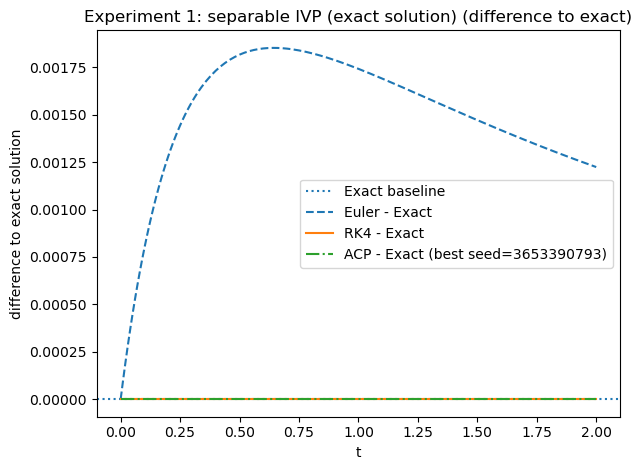

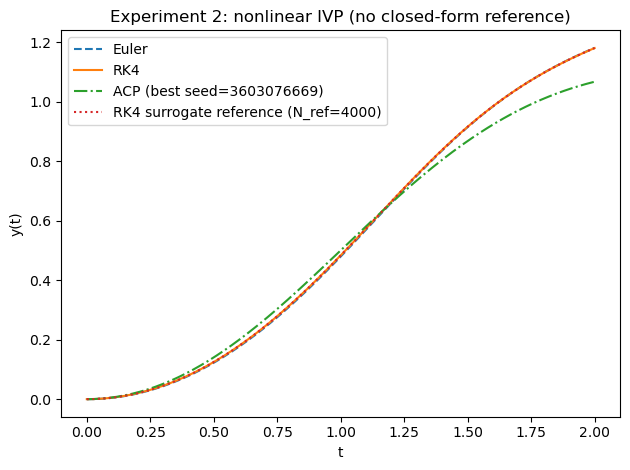

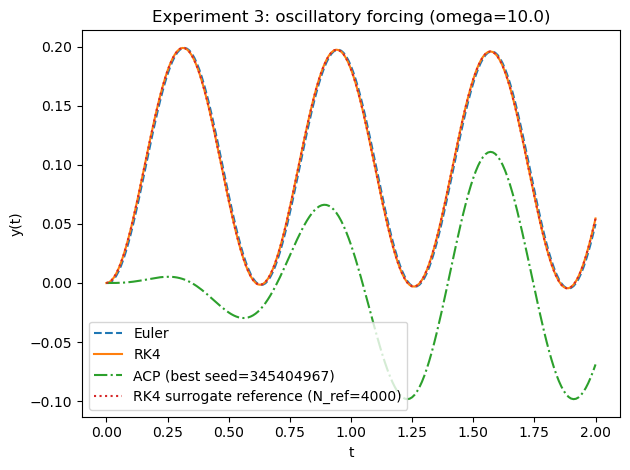

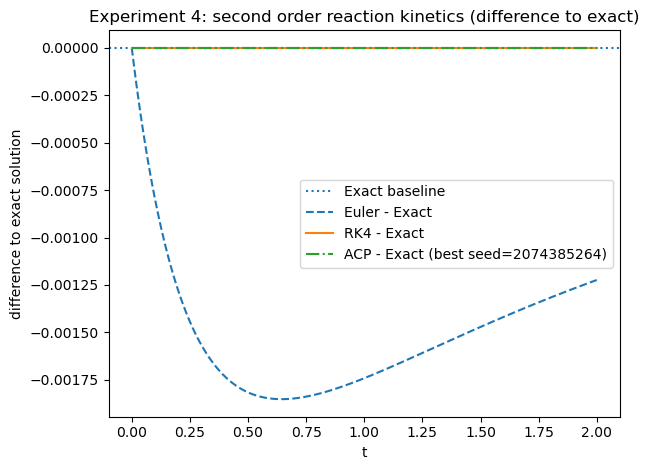

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# ---------------------------------------------------------------------
# Helper wrappers for scalar / vectorised RHS forms
# ---------------------------------------------------------------------

def vec_from_scalar_f(f_scalar):
    """
    Convert a scalar RHS f(t, y) into a vectorised function compatible with the
    common residual evaluator and plotting code.
    """
    def f_vec(t, y):
        t = np.asarray(t, dtype=float)
        y = np.asarray(y, dtype=float)
        return np.vectorize(f_scalar)(t, y)
    return f_vec


def scalar_from_vec_f(f_vec):
    """
    Convert a vectorised RHS into a scalar RHS suitable for Euler / RK4 loops.
    """
    def f_scalar(t, y):
        return float(f_vec(np.array([t], dtype=float), np.array([y], dtype=float))[0])
    return f_scalar


def build_graph_from_symbol_set(aco_symbol_set, tau0=1.0):
    """
    Build a fresh ACP graph from a symbol-set dictionary.

    A fresh graph is used for each independent stochastic run so that pheromone
    state does not leak across seeds.
    """
    return Graph(
        aco_symbol_set["constants"],
        aco_symbol_set["variables"],
        aco_symbol_set["unary_funcs"],
        aco_symbol_set["binary_ops"],
        tau0=tau0
    )


def generate_random_seeds(n_seeds=30, seed_low=0, seed_high=2**32 - 1):
    """
    Generate explicit integer seeds for repeated ACP runs.

    Seeds are kept within the uint32-safe range accepted by NumPy's legacy
    seeding API because both random.seed(...) and np.random.seed(...) are used.
    """
    rng = np.random.default_rng()
    seeds = rng.integers(seed_low, seed_high + 1, size=n_seeds, dtype=np.uint32)
    return [int(s) for s in seeds]


# ---------------------------------------------------------------------
# ACP runner: one seed, export N and 2N using the same best expression
# ---------------------------------------------------------------------

def run_aco_seed_export_two_grids(prob, aco_symbol_set, acp_cfg, eval_cfg, N, seed, verbose=False):
    """
    Run ACP once for a given seed from a fresh graph and export the resulting
    best expression on both the N-grid and the 2N-grid.

    This allows the final Chapter 4 comparison to use the same best symbolic
    expression under both grid resolutions.
    """
    graph = build_graph_from_symbol_set(aco_symbol_set, tau0=1.0)
    acp_cfg_seeded = ACPConfig(**{**acp_cfg.__dict__, "seed": int(seed)})

    outN = run_and_export_grid(
        problem=prob,
        graph=graph,
        acp_cfg=acp_cfg_seeded,
        eval_cfg=eval_cfg,
        N_grid=N,
        verbose=verbose
    )

    best_expr = outN["best_expr_simplified"]
    t2N, y2N = export_grid_solution(best_expr, prob.t0, prob.T, 2 * N)

    return {
        "seed": int(seed),
        "best_expr": best_expr,
        "fitness": outN["optimisation_error"],
        "tN": outN["t_grid"],
        "yN": outN["y_grid"],
        "t2N": t2N,
        "y2N": y2N,
    }


# ---------------------------------------------------------------------
# Plot-only surrogate reference for experiments without exact solution
# ---------------------------------------------------------------------

def build_rk4_surrogate_reference_on_common_grid(f_scalar, prob, N, ref_factor=20):
    """
    Build a fine-grid RK4 surrogate reference and interpolate it back to the
    common N-grid.

    This surrogate reference is used only for visual comparison in experiments
    without a closed-form exact solution. It does not alter the formal midpoint
    residual comparison, which remains based on the shared N-grid and 2N-grid.
    """
    N_ref = int(ref_factor * N)
    if N_ref <= N:
        N_ref = 2 * N

    t_ref, y_ref = solve_rk4(f_scalar, prob.t0, prob.T, prob.y0, N_ref)

    t_common = np.linspace(prob.t0, prob.T, N + 1)
    y_ref_common = np.interp(t_common, t_ref, y_ref)

    return {
        "N_ref": N_ref,
        "t_ref": t_ref,
        "y_ref": y_ref,
        "t_common": t_common,
        "y_ref_common": y_ref_common,
    }


# ---------------------------------------------------------------------
# One experiment: Euler/RK4 once, ACP over many seeds, keep best ACP run
# ---------------------------------------------------------------------

def run_experiment_multi_seed(
    name,
    prob,
    f_vec,
    N=200,
    seeds=None,
    n_seed_trials=30,
    exact_fn=None,
    include_exact=False,
    exact_expr=None,
    rhs_expr=None,
    t_sym=None,
    y_sym=None,
    report_continuous_J=False,
    plot_error_to_exact=False,
    plot_surrogate_reference=False,
    surrogate_ref_factor=20,
    aco_symbol_set=None,
    aco_params=None,
    eval_params=None,
    verbose_aco=False,
    save_plot=True
):
    """
    Run one experiment under the common Chapter 4 protocol.

    For Euler and RK4:
        - solve once on the N-grid and 2N-grid
        - compute J_N(y) and J_2N(y)

    For ACP:
        - run many stochastic seeds
        - export each best expression to the N-grid and 2N-grid
        - rank runs by J_N(y)
        - keep the best run for reporting and plotting

    Optional features:
        - J[Y] for exact / symbolic expressions when available
        - deviation-from-exact plot for Experiment 1
        - surrogate RK4 reference line for experiments without exact solution
    """
    print(f"\n=== {name} ===")

    # Scalar RHS for the time-stepping solvers
    f_scalar = scalar_from_vec_f(f_vec)

    # Euler / RK4 on N and 2N
    tE, yE = solve_euler(f_scalar, prob.t0, prob.T, prob.y0, N)
    tE2, yE2 = solve_euler(f_scalar, prob.t0, prob.T, prob.y0, 2 * N)
    tR, yR = solve_rk4(f_scalar, prob.t0, prob.T, prob.y0, N)
    tR2, yR2 = solve_rk4(f_scalar, prob.t0, prob.T, prob.y0, 2 * N)

    JE = compute_J_midpoint(tE, yE, f_vec)
    JE2 = compute_J_midpoint(tE2, yE2, f_vec)
    JR = compute_J_midpoint(tR, yR, f_vec)
    JR2 = compute_J_midpoint(tR2, yR2, f_vec)

    # Exact reference sampled on the common grid when available
    JX = JX2 = None
    yX = yX2 = None
    if include_exact and exact_fn is not None:
        yX = exact_fn(tE)
        yX2 = exact_fn(tE2)
        JX = compute_J_midpoint(tE, yX, f_vec)
        JX2 = compute_J_midpoint(tE2, yX2, f_vec)

    # Continuous J[Y] for the exact expression when available
    exact_continuous = None
    if (
        report_continuous_J
        and include_exact
        and exact_expr is not None
        and rhs_expr is not None
        and t_sym is not None
        and y_sym is not None
    ):
        exact_continuous = compute_J_continuous_from_expr(
            y_expr=exact_expr,
            rhs_expr=rhs_expr,
            t_sym=t_sym,
            y_sym=y_sym,
            t0=prob.t0,
            T=prob.T,
        )

    # Default ACP symbol set
    if aco_symbol_set is None:
        aco_symbol_set = {
            "constants": [str(i) for i in range(0, 10)],
            "variables": ["t"],
            "unary_funcs": ["id"],
            "binary_ops": ["+", "-", "*", "/"],
        }

    # Default ACP / evaluator settings
    if aco_params is None:
        aco_params = dict(
            max_depth=3,
            ants=60,
            generations=150,
            rho=0.3,
            elite_frac=0.2,
            q=0.5,
            seed=None
        )
    else:
        aco_params = {**aco_params, "seed": None}

    if eval_params is None:
        eval_params = dict(
            Ns=80,
            bc_weight=80.0,
            complexity_weight=1e-4,
            clip_value=1e6
        )

    acp_cfg = ACPConfig(**aco_params)
    eval_cfg = EvalConfig(**eval_params)

    # Generate random seeds if none were supplied explicitly
    if seeds is None:
        seeds = generate_random_seeds(n_seeds=n_seed_trials)

    # Run ACP independently for all seeds
    all_aco_runs = []

    for s in seeds:
        out = run_aco_seed_export_two_grids(
            prob=prob,
            aco_symbol_set=aco_symbol_set,
            acp_cfg=acp_cfg,
            eval_cfg=eval_cfg,
            N=N,
            seed=s,
            verbose=verbose_aco
        )

        JN = compute_J_midpoint(out["tN"], out["yN"], f_vec)
        J2N = compute_J_midpoint(out["t2N"], out["y2N"], f_vec)

        out["J_N"] = JN
        out["J_2N"] = J2N
        all_aco_runs.append(out)

    finite_runs = [r for r in all_aco_runs if np.isfinite(r["J_N"])]
    finite_runs.sort(key=lambda r: r["J_N"])

    top5_runs = finite_runs[:5]
    best_run = top5_runs[0] if len(top5_runs) > 0 else None

    # Print discrete midpoint metric values
    print("\nJ_N(y) values (midpoint metric):")
    if include_exact and exact_fn is not None:
        print(f"  Exact:     J_N(y)={JX:.6e}   J_2N(y)={JX2:.6e}")
    print(f"  Euler:     J_N(y)={JE:.6e}   J_2N(y)={JE2:.6e}")
    print(f"  RK4:       J_N(y)={JR:.6e}   J_2N(y)={JR2:.6e}")

    aco_continuous = None

    if best_run is None:
        print("  ACO(best): (all seed runs invalid)")
        JA = JA2 = float("inf")
        best_seed = None
        best_expr = None
        best_fit = None
        tA = tE
        yA = np.full_like(tE, np.nan, dtype=float)
    else:
        JA = best_run["J_N"]
        JA2 = best_run["J_2N"]
        best_seed = best_run["seed"]
        best_expr = best_run["best_expr"]
        best_fit = best_run["fitness"]
        tA = best_run["tN"]
        yA = best_run["yN"]

        print(f"  ACO(best): J_N(y)={JA:.6e}   J_2N(y)={JA2:.6e}")

        print("\nTop 5 ACP seeds by J_N(y):")
        for k, r in enumerate(top5_runs, start=1):
            print(
                f"  #{k}: seed={r['seed']}, "
                f"J_N(y)={r['J_N']:.6e}, "
                f"J_2N(y)={r['J_2N']:.6e}, "
                f"fitness={r['fitness']:.6e}, "
                f"expr={r['best_expr']}"
            )

        # Continuous J[Y] for the best ACP expression when available
        if (
            report_continuous_J
            and rhs_expr is not None
            and t_sym is not None
            and y_sym is not None
            and best_expr is not None
        ):
            aco_continuous = compute_J_continuous_from_expr(
                y_expr=best_expr,
                rhs_expr=rhs_expr,
                t_sym=t_sym,
                y_sym=y_sym,
                t0=prob.t0,
                T=prob.T,
            )

    # Print continuous functional values when available
    if exact_continuous is not None or aco_continuous is not None:
        print("\nExpressions used for J[Y]:")
        if exact_expr is not None:
            print(f"  Exact Y(t):    {sp.simplify(exact_expr)}")
        if best_expr is not None:
            print(f"  ACP best Y(t): {sp.simplify(best_expr)}")

        print("\nJ[Y] values (continuous residual functional):")
        if exact_continuous is not None:
            print(
                f"  Exact:     J[Y]={exact_continuous['J_float']:.6e} "
                f"({exact_continuous['status']})"
            )
        if aco_continuous is not None:
            print(
                f"  ACP(best): J[Y]={aco_continuous['J_float']:.6e} "
                f"({aco_continuous['status']})"
            )

    # -----------------------------------------------------------------
    # Plotting
    # -----------------------------------------------------------------

    plt.figure()

    if plot_error_to_exact and include_exact and exact_fn is not None:
        # Experiment 1: show deviations from the exact solution
        y_exact_plot = exact_fn(tE)

        plt.axhline(0.0, linestyle=":", label="Exact baseline")
        plt.plot(tE, yE - y_exact_plot, label="Euler - Exact", linestyle="--")
        plt.plot(tR, yR - y_exact_plot, label="RK4 - Exact", linestyle="-")
        if best_run is not None:
            plt.plot(
                tA, yA - y_exact_plot,
                label=f"ACP - Exact (best seed={best_seed})",
                linestyle="-."
            )

        plt.xlabel("t")
        plt.ylabel("difference to exact solution")
        plt.title(name + " (difference to exact)")

    elif plot_surrogate_reference:
        # Experiments 2 and 3: original solution curves plus a surrogate reference
        ref_data = build_rk4_surrogate_reference_on_common_grid(
            f_scalar=f_scalar,
            prob=prob,
            N=N,
            ref_factor=surrogate_ref_factor
        )
        t_ref_common = ref_data["t_common"]
        y_ref_common = ref_data["y_ref_common"]
        N_ref = ref_data["N_ref"]

        print(f"\nPlot-only surrogate reference: fine-grid RK4 with N_ref={N_ref}, interpolated back to the common N-grid.")

        plt.plot(tE, yE, label="Euler", linestyle="--")
        plt.plot(tR, yR, label="RK4", linestyle="-")
        if best_run is not None:
            plt.plot(tA, yA, label=f"ACP (best seed={best_seed})", linestyle="-.")
        plt.plot(
            t_ref_common, y_ref_common,
            label=f"RK4 surrogate reference (N_ref={N_ref})",
            linestyle=":"
        )

        plt.xlabel("t")
        plt.ylabel("y(t)")
        plt.title(name)

    else:
        # Absolute solution curves (used when an exact solution is available and
        # an error-to-exact plot is not requested)
        if include_exact and exact_fn is not None:
            plt.plot(tE, exact_fn(tE), label="Exact", linestyle=":")
        plt.plot(tE, yE, label="Euler", linestyle="--")
        plt.plot(tR, yR, label="RK4", linestyle="-")
        if best_run is not None:
            plt.plot(tA, yA, label=f"ACP (best seed={best_seed})", linestyle="-.")

        plt.xlabel("t")
        plt.ylabel("y(t)")
        plt.title(name)

    plt.legend()
    plt.tight_layout()

    if save_plot:
        safe_name = name.replace(" ", "_").replace(":", "").replace("/", "_")
        plt.savefig(f"{safe_name}.png", dpi=200)

    # -----------------------------------------------------------------
    # Collect results
    # -----------------------------------------------------------------

    results = {
        "name": name,
        "N": N,
        "tested_seeds": list(seeds),

        # Discrete midpoint residual values
        "J_N_Euler": JE,
        "J_2N_Euler": JE2,
        "J_N_RK4": JR,
        "J_2N_RK4": JR2,
        "J_N_ACO": JA,
        "J_2N_ACO": JA2,

        # Legacy keys kept for convenience
        "J_Euler": JE,
        "J_Euler_2N": JE2,
        "J_RK4": JR,
        "J_RK4_2N": JR2,
        "J_ACO": JA,
        "J_ACO_2N": JA2,

        "ACO_top5": [
            {
                "rank": i + 1,
                "seed": r["seed"],
                "J_N": r["J_N"],
                "J_2N": r["J_2N"],
                "fitness": r["fitness"],
                "expr": str(r["best_expr"]),
            }
            for i, r in enumerate(top5_runs)
        ],
        "ACO_best_seed": best_seed,
        "ACO_best_expr": None if best_expr is None else str(best_expr),
        "ACO_best_fitness": best_fit,

        # Continuous functional values where available
        "JY_Exact": None if exact_continuous is None else exact_continuous["J_float"],
        "JY_Exact_status": None if exact_continuous is None else exact_continuous["status"],
        "JY_ACO": None if aco_continuous is None else aco_continuous["J_float"],
        "JY_ACO_status": None if aco_continuous is None else aco_continuous["status"],
    }

    if include_exact and exact_fn is not None:
        results["J_N_Exact"] = JX
        results["J_2N_Exact"] = JX2
        results["J_Exact"] = JX
        results["J_Exact_2N"] = JX2

    return results


# ---------------------------------------------------------------------
# Full Chapter 4 experiment suite
# ---------------------------------------------------------------------

def run_all_four_experiments_multi_seed(
    N=200,
    T=2.0,
    omega=10.0,
    seeds=None,
    n_seed_trials=30,
    verbose_aco=False
):
    """
    Run the full Chapter 4 experiment set.

    Experiment 1:
        Closed-form separable benchmark with exact solution.
    Experiment 2:
        Nonlinear IVP without closed-form exact solution.
    Experiment 3:
        Oscillatory / rapidly varying forcing.
    Experiment 4:
        Application-motivated second-order reaction kinetics model.

    Returns
    -------
    list of dict
        One results dictionary per experiment.
    """
    all_results = []

    t_sym = sp.Symbol("t", real=True)
    y_sym = sp.Symbol("y", real=True)

    # ===============================================================
    # Experiment 1: y' = (1 - y)^2, y(0) = 0, exact y = t / (1 + t)
    # ===============================================================

    def f1_scalar(t, y):
        return (1.0 - y) ** 2

    f1_vec = vec_from_scalar_f(f1_scalar)

    def y1_exact(t):
        t = np.asarray(t, dtype=float)
        return t / (1.0 + t)

    y1_exact_expr = t_sym / (1 + t_sym)
    f1_rhs_expr = (1 - y_sym) ** 2

    prob1 = ODEProblem(t0=0.0, T=T, y0=0.0, f=f1_vec)

    sym1 = {
        "constants": [str(i) for i in range(0, 10)],
        "variables": ["t"],
        "unary_funcs": ["id"],
        "binary_ops": ["+", "-", "*", "/"],
    }

    res1 = run_experiment_multi_seed(
        name="Experiment 1: separable IVP (exact solution)",
        prob=prob1,
        f_vec=f1_vec,
        N=N,
        seeds=seeds,
        n_seed_trials=n_seed_trials,
        exact_fn=y1_exact,
        include_exact=True,
        exact_expr=y1_exact_expr,
        rhs_expr=f1_rhs_expr,
        t_sym=t_sym,
        y_sym=y_sym,
        report_continuous_J=True,
        plot_error_to_exact=True,
        aco_symbol_set=sym1,
        aco_params=dict(
            max_depth=4,
            ants=80,
            generations=200,
            rho=0.3,
            elite_frac=0.2,
            q=0.5,
            seed=None
        ),
        eval_params=dict(
            Ns=120,
            bc_weight=80.0,
            complexity_weight=1e-4,
            clip_value=1e6
        ),
        verbose_aco=verbose_aco
    )
    all_results.append(res1)

    # ===============================================================
    # Experiment 2: y' = t - y^3, y(0) = 0
    # ===============================================================

    def f2_scalar(t, y):
        return t - y**3

    f2_vec = vec_from_scalar_f(f2_scalar)
    prob2 = ODEProblem(t0=0.0, T=T, y0=0.0, f=f2_vec)

    sym2 = {
        "constants": [str(i) for i in range(0, 10)],
        "variables": ["t"],
        "unary_funcs": ["id"],
        "binary_ops": ["+", "-", "*", "/"],
    }

    res2 = run_experiment_multi_seed(
        name="Experiment 2: nonlinear IVP (no closed-form reference)",
        prob=prob2,
        f_vec=f2_vec,
        N=N,
        seeds=seeds,
        n_seed_trials=n_seed_trials,
        include_exact=False,
        plot_surrogate_reference=True,
        surrogate_ref_factor=20,
        aco_symbol_set=sym2,
        aco_params=dict(
            max_depth=4,
            ants=100,
            generations=250,
            rho=0.3,
            elite_frac=0.2,
            q=0.5,
            seed=None
        ),
        eval_params=dict(
            Ns=150,
            bc_weight=100.0,
            complexity_weight=1e-4,
            clip_value=1e6
        ),
        verbose_aco=verbose_aco
    )
    all_results.append(res2)

    # ===============================================================
    # Experiment 3: y' = sin(omega t) - y^3, y(0) = 0
    # ===============================================================

    def f3_vec(t, y):
        t = np.asarray(t, dtype=float)
        y = np.asarray(y, dtype=float)
        return np.sin(omega * t) - y**3

    prob3 = ODEProblem(t0=0.0, T=T, y0=0.0, f=f3_vec)

    sym3 = {
        "constants": [str(i) for i in range(0, 10)],
        "variables": ["t"],
        "unary_funcs": ["sin", "cos", "id"],
        "binary_ops": ["+", "-", "*", "/"],
    }

    res3 = run_experiment_multi_seed(
        name=f"Experiment 3: oscillatory forcing (omega={omega})",
        prob=prob3,
        f_vec=f3_vec,
        N=N,
        seeds=seeds,
        n_seed_trials=n_seed_trials,
        include_exact=False,
        plot_surrogate_reference=True,
        surrogate_ref_factor=20,
        aco_symbol_set=sym3,
        aco_params=dict(
            max_depth=4,
            ants=120,
            generations=300,
            rho=0.3,
            elite_frac=0.2,
            q=0.5,
            seed=None
        ),
        eval_params=dict(
            Ns=160,
            bc_weight=120.0,
            complexity_weight=1e-4,
            clip_value=1e6
        ),
        verbose_aco=verbose_aco
    )
    all_results.append(res3)

    # ===============================================================
    # Experiment 4: application-motivated second-order reaction kinetics
    # y' = -y^2, y(0) = 1, exact y = 1 / (1 + t)
    # ===============================================================

    def f4_scalar(t, y):
        return -(y ** 2)

    f4_vec = vec_from_scalar_f(f4_scalar)

    def y4_exact(t):
        t = np.asarray(t, dtype=float)
        return 1.0 / (1.0 + t)

    y4_exact_expr = 1 / (1 + t_sym)
    f4_rhs_expr = -(y_sym ** 2)

    prob4 = ODEProblem(t0=0.0, T=T, y0=1.0, f=f4_vec)

    sym4 = {
        "constants": [str(i) for i in range(0, 10)],
        "variables": ["t"],
        "unary_funcs": ["id"],
        "binary_ops": ["+", "-", "*", "/"],
    }

    res4 = run_experiment_multi_seed(
        name="Experiment 4: second order reaction kinetics",
        prob=prob4,
        f_vec=f4_vec,
        N=N,
        seeds=seeds,
        n_seed_trials=n_seed_trials,
        exact_fn=y4_exact,
        include_exact=True,
        exact_expr=y4_exact_expr,
        rhs_expr=f4_rhs_expr,
        t_sym=t_sym,
        y_sym=y_sym,
        report_continuous_J=True,
        plot_error_to_exact=True,
        aco_symbol_set=sym4,
        aco_params=dict(
            max_depth=4,
            ants=80,
            generations=220,
            rho=0.3,
            elite_frac=0.2,
            q=0.5,
            seed=None
        ),
        eval_params=dict(
            Ns=120,
            bc_weight=80.0,
            complexity_weight=1e-4,
            clip_value=1e6
        ),
        verbose_aco=verbose_aco
    )
    all_results.append(res4)

    # -----------------------------------------------------------------
    # Summary print
    # -----------------------------------------------------------------

    print("\n=== Summary (best ACP over seeds) ===")
    for r in all_results:
        print("\n", r["name"])
        print("  J_N(y) [midpoint metric]:")
        if "J_Exact" in r:
            print(f"    Exact:  {r['J_Exact']:.6e}   {r['J_Exact_2N']:.6e}")
        print(f"    Euler:  {r['J_Euler']:.6e}   {r['J_Euler_2N']:.6e}")
        print(f"    RK4:    {r['J_RK4']:.6e}   {r['J_RK4_2N']:.6e}")
        print(f"    ACP:    {r['J_ACO']:.6e}   {r['J_ACO_2N']:.6e}")

        if r.get("JY_Exact") is not None or r.get("JY_ACO") is not None:
            print("  J[Y] [continuous functional]:")
            if r.get("JY_Exact") is not None:
                print(f"    Exact:  {r['JY_Exact']:.6e}   ({r['JY_Exact_status']})")
            if r.get("JY_ACO") is not None:
                print(f"    ACP:    {r['JY_ACO']:.6e}   ({r['JY_ACO_status']})")

    return all_results


# ---------------------------------------------------------------------
# Run the full experiment suite
# ---------------------------------------------------------------------

all_results = run_all_four_experiments_multi_seed(
    N=200,
    T=2.0,
    omega=10.0,
    seeds=None,
    n_seed_trials=30,
    verbose_aco=False
)
